# ASONAM Rhetorical Analysis Pipeline

End-to-end analysis of rhetorical techniques in YouTube comments and transcripts.

**Methodology:**
1. **Comments**: Span-level rhetorical annotations → user rhetorical profiles → cluster profiles (KMeans on stance + media diet)
2. **Transcripts**: Same annotations → channel-group profiles (leaning × source type)
3. **Correlation**: Test whether matched (leaning × source) pairs correlate more than non-matched pairs (permutation test, 4! = 24)

**Two-pass design for memory efficiency:**
- **Cell 3 (pass 1)**: Scans all comment files, stores only `(stance, channel_feat)` per comment — lightweight, no text/spans in RAM.
- **Cell 5 (pass 2)**: Re-reads all comment files, processes span annotations only for clustered users — keeps only `(user, category, coverage_share)` rows.

**Intensity metric**: `weighted_intensity = prevalence × mean_intensity_pct`
where `intensity_pct` is the within-category percentile rank of `coverage_share` across all corpus observations.
This normalises structural length differences across rhetorical categories.

**⚠️ Before running Cell 7**: Inspect the cluster × channel-feature heatmap in Cell 4 and verify `CLUSTER_TO_GROUP` in Cell 1.

In [1]:
import json
import os
import glob
from itertools import permutations
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── DATA PATHS ──────────────────────────────────────────────────────────────
COMMENTS_PATH    = "/path/to/comments/"
TRANSCRIPTS_PATH = "/path/to/transcripts/"
LABEL_MAP_FILE   = "/path/to/label_mapping.txt"
OUTPUT_DIR       = "output"

# ── FILTERING PARAMETERS ────────────────────────────────────────────────────
START_YEAR            = 2020
END_YEAR              = 2024
MIN_COMMENTS_PER_USER = 3
MIN_WORDS_TRANSCRIPT  = 350
MIN_VIDEOS_CHANNEL    = 30

# ── CLUSTERING ──────────────────────────────────────────────────────────────
N_CLUSTERS    = 4
RANDOM_STATE  = 42
STANCE_WEIGHT = 1.0

# ── ORDERING ────────────────────────────────────────────────────────────────
CATEGORY_ORDER = ["Reputation", "Emotions", "Justification", "Call", "Simplification"]
GROUP_ORDER    = ["Left-Content", "Left-News", "Right-Content", "Right-News"]

# CLUSTER_TO_GROUP is auto-detected in Cell 4 from the data.
# Do NOT define it here — it will be overwritten.

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config loaded. Output dir:", OUTPUT_DIR)

Config loaded. Output dir: output


In [2]:
LABEL_MAPPING = {}
with open(LABEL_MAP_FILE, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if "\t" in line:
            tech, cat = line.split("\t", 1)
        elif "->" in line:
            tech, cat = line.split("->", 1)
        else:
            continue
        tech = tech.strip().strip('"').lower()   # strip whitespace AND surrounding quotes
        cat  = cat.strip()
        if cat.lower() != "distraction":
            LABEL_MAPPING[tech] = cat

print(f"Loaded {len(LABEL_MAPPING)} technique \u2192 category mappings (distraction excluded)")
for tech, cat in sorted(LABEL_MAPPING.items()):
    print(f"  {tech!r:55s} \u2192 {cat}")

Loaded 18 technique → category mappings (distraction excluded)
  'appeal to authority'                                   → Justification
  'appeal to fear, prejudice'                             → Justification
  'appeal to hypocrisy (to quoque)'                       → Reputation
  'appeal to pity'                                        → Justification
  'appeal to popularity (bandwagon)'                      → Justification
  'appeal to time'                                        → Call
  'appeal to values/flag waving'                          → Justification
  'black-and-white fallacy'                               → Simplification
  'causal oversimplification'                             → Simplification
  'exaggeration or minimisation'                          → Emotions
  'intentional vagueness'                                 → Emotions
  'loaded language'                                       → Emotions
  'name calling'                                          → Reputation
  '

In [3]:
# ── HELPER (used in Cells 3, 5, 6) ──────────────────────────────────────────
def merged_coverage(intervals, text_len):
    """Return fraction of [0, text_len) covered by merged intervals."""
    if not intervals or text_len == 0:
        return 0.0
    cleaned = []
    for s, e in intervals:
        try:
            s, e = int(s), int(e)
            if s < e:
                cleaned.append((max(0, s), min(text_len, e)))
        except (TypeError, ValueError):
            continue
    if not cleaned:
        return 0.0
    cleaned.sort()
    merged = [list(cleaned[0])]
    for s, e in cleaned[1:]:
        if s <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return sum(e - s for s, e in merged) / text_len


# ── PASS 1: collect only (stance, channel_feat) per comment ──────────────────
# CommentText and span_predictions are NOT stored — they are re-read in Cell 5.
# This keeps memory usage to ~200 MB instead of tens of GB.
print("Scanning comment files (pass 1: stance + channel features only)...")
all_jsonl = sorted(glob.glob(os.path.join(COMMENTS_PATH, "**", "*.jsonl"), recursive=True))
print(f"  Found {len(all_jsonl):,} JSONL files")

# user_raw: AuthorName -> list of tiny dicts {stance, channel_feat}
user_raw = defaultdict(list)
n_total = n_skipped_year = n_skipped_stance = 0

for file_idx, fp in enumerate(all_jsonl):
    if file_idx % 500 == 0:
        print(f"  [{file_idx:>5}/{len(all_jsonl)}] comments so far: {n_total:,}", flush=True)
    with open(fp, encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            ts = str(rec.get("Timestamp", ""))
            try:
                year = int(ts[:4])
            except ValueError:
                continue
            if not (START_YEAR <= year <= END_YEAR):
                n_skipped_year += 1
                continue

            stance = rec.get("predicted_stance")
            if stance not in {0, 1, 2}:
                n_skipped_stance += 1
                continue

            author = rec.get("AuthorName")
            if not author:
                continue

            leaning = rec.get("ChannelLeaning", "")
            source  = rec.get("Source", "")
            n_total += 1
            # Store ONLY what is needed for clustering — no text, no spans
            user_raw[author].append({
                "stance":       stance,
                "channel_feat": f"{leaning}-{source}",
            })

print(f"\nParsed {n_total:,} comments from {len(user_raw):,} unique users")
print(f"Skipped {n_skipped_year:,} (year) | {n_skipped_stance:,} (invalid stance)")


# ── BUILD user_summary ───────────────────────────────────────────────────────
rows = []
for author, comments in user_raw.items():
    if len(comments) < MIN_COMMENTS_PER_USER:
        continue
    stances = [c["stance"] for c in comments]
    rows.append({
        "AuthorName":  author,
        "n_comments":  len(comments),
        "stance_mean": float(np.mean(stances)),
    })

user_summary = pd.DataFrame(rows).set_index("AuthorName")
user_summary["stance_label"] = user_summary["stance_mean"].apply(
    lambda x: "contra" if x < 0.8 else ("pro" if x > 1.0 else "uncertain")
)


# ── BUILD channel_share ──────────────────────────────────────────────────────
chan_counts = defaultdict(Counter)
for author in user_summary.index:
    for c in user_raw[author]:
        chan_counts[author][c["channel_feat"]] += 1

channel_share_raw = (
    pd.DataFrame.from_dict(chan_counts, orient="index")
    .reindex(user_summary.index)
    .fillna(0)
)
channel_share = channel_share_raw.div(channel_share_raw.sum(axis=1), axis=0)


# ── REPORT ───────────────────────────────────────────────────────────────────
print(f"\nUsers after MIN_COMMENTS_PER_USER ({MIN_COMMENTS_PER_USER}) filter: {len(user_summary):,}")
print(f"Comments for analysis: {int(user_summary['n_comments'].sum()):,}")
print(f"Channel features found: {list(channel_share.columns)}")
print("\nuser_summary shape:", user_summary.shape)
print(user_summary.head())

Scanning comment files (pass 1: stance + channel features only)...
  Found 6,172 JSONL files
  [    0/6172] comments so far: 0
  [  500/6172] comments so far: 286,010
  [ 1000/6172] comments so far: 567,447
  [ 1500/6172] comments so far: 1,001,681
  [ 2000/6172] comments so far: 1,172,259
  [ 2500/6172] comments so far: 1,338,511
  [ 3000/6172] comments so far: 1,686,748
  [ 3500/6172] comments so far: 2,081,873
  [ 4000/6172] comments so far: 2,420,693
  [ 4500/6172] comments so far: 2,746,174
  [ 5000/6172] comments so far: 3,124,043
  [ 5500/6172] comments so far: 3,655,524
  [ 6000/6172] comments so far: 4,242,454

Parsed 4,541,061 comments from 1,257,598 unique users
Skipped 25,234 (year) | 0 (invalid stance)

Users after MIN_COMMENTS_PER_USER (3) filter: 358,882
Comments for analysis: 3,431,825
Channel features found: ['Left-News', 'Left-Content', 'Right-News', 'Right-Content']

user_summary shape: (358882, 3)
                       n_comments  stance_mean stance_label
AuthorNam

Feature matrix: (358882, 5) (users × features)
Auto-detected CLUSTER_TO_GROUP:
  Cluster 0 → 'Left-News'  (max channel share = 0.865)
  Cluster 1 → 'Right-Content'  (max channel share = 0.838)
  Cluster 2 → 'Right-News'  (max channel share = 0.844)
  Cluster 3 → 'Left-Content'  (max channel share = 0.886)


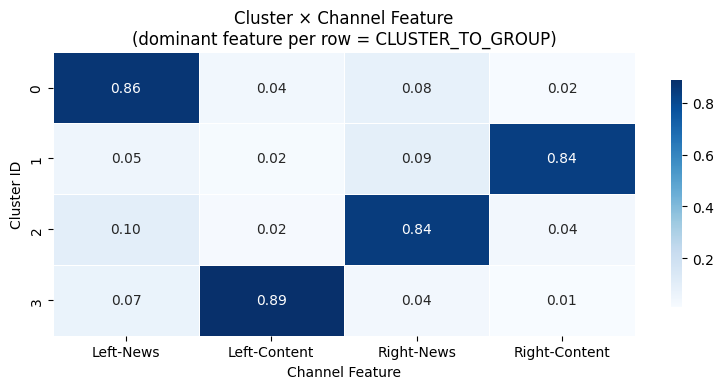


Cluster summary:
         n_users  mean_stance    group_label
cluster                                     
0         107801     0.834729      Left-News
1          42263     0.744306  Right-Content
2         134534     0.565690     Right-News
3          74284     1.094107   Left-Content

analysis_users shape: (358882, 4)


In [4]:
# ── BUILD FEATURE MATRIX ─────────────────────────────────────────────────────
feature_df = channel_share.copy()
feature_df["stance_feature"] = (
    user_summary.loc[feature_df.index, "stance_mean"] / 2.0
) * STANCE_WEIGHT
feature_df = feature_df.fillna(0)
print(f"Feature matrix: {feature_df.shape} (users × features)")

# ── FIT KMEANS ────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(feature_df.values)

analysis_users = user_summary.loc[feature_df.index].copy()
analysis_users["cluster"] = cluster_labels

# ── AUTO-DETECT CLUSTER_TO_GROUP ──────────────────────────────────────────────
# For each cluster, find the channel feature with the highest mean share.
# The cluster whose users comment most on "Left-News" channels IS the Left-News cluster.
# This is deterministic from the data — no manual mapping needed.

channel_cols = [c for c in feature_df.columns if c != "stance_feature"]
cluster_channel_profile = (
    feature_df[channel_cols]
    .assign(_cluster=cluster_labels)
    .groupby("_cluster")
    .mean()
)
cluster_channel_profile.index.name = "cluster"

CLUSTER_TO_GROUP = {
    cluster_id: cluster_channel_profile.loc[cluster_id].idxmax()
    for cluster_id in range(N_CLUSTERS)
}

# Sanity check: each group must appear exactly once
assert len(set(CLUSTER_TO_GROUP.values())) == N_CLUSTERS, (
    f"CLUSTER_TO_GROUP has duplicates: {CLUSTER_TO_GROUP}\n"
    "Clusters are not cleanly separated by channel type. "
    "Check channel_share columns or increase N_CLUSTERS."
)

print("Auto-detected CLUSTER_TO_GROUP:")
for k, v in sorted(CLUSTER_TO_GROUP.items()):
    top_val = cluster_channel_profile.loc[k].max()
    print(f"  Cluster {k} → '{v}'  (max channel share = {top_val:.3f})")

# ── CLUSTER × CHANNEL HEATMAP (verification) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    cluster_channel_profile,
    cmap="Blues", annot=True, fmt=".2f",
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title("Cluster × Channel Feature\n(dominant feature per row = CLUSTER_TO_GROUP)")
ax.set_xlabel("Channel Feature")
ax.set_ylabel("Cluster ID")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cluster_channel_heatmap.png", dpi=150)
plt.show()

# ── CLUSTER SUMMARY ───────────────────────────────────────────────────────────
cluster_summary = analysis_users.groupby("cluster").agg(
    n_users    =("n_comments", "count"),
    mean_stance=("stance_mean", "mean"),
)
cluster_summary["group_label"] = cluster_summary.index.map(CLUSTER_TO_GROUP)
print("\nCluster summary:")
print(cluster_summary.to_string())
print(f"\nanalysis_users shape: {analysis_users.shape}")


Processing spans for 358,882 clustered users (pass 2)...
  [    0/6172] span rows so far: 0
  [  500/6172] span rows so far: 386,473
  [ 1000/6172] span rows so far: 776,153
  [ 1500/6172] span rows so far: 1,322,690
  [ 2000/6172] span rows so far: 1,563,557
  [ 2500/6172] span rows so far: 1,799,238
  [ 3000/6172] span rows so far: 2,291,740
  [ 3500/6172] span rows so far: 2,942,207
  [ 4000/6172] span rows so far: 3,510,698
  [ 4500/6172] span rows so far: 4,059,340
  [ 5000/6172] span rows so far: 4,583,496
  [ 5500/6172] span rows so far: 5,285,636
  [ 6000/6172] span rows so far: 6,157,422

comment_df shape: (6533290, 3)
               user       category  coverage_share
0     @traveler5973           Call        1.000000
1      @eddie-xr6mn     Reputation        1.000000
2  @adrianaticas450  Justification        0.375479
3  @adrianaticas450       Emotions        0.042146
4  @adrianaticas450     Reputation        0.111111

user_cat shape: (1406340, 9)
                            

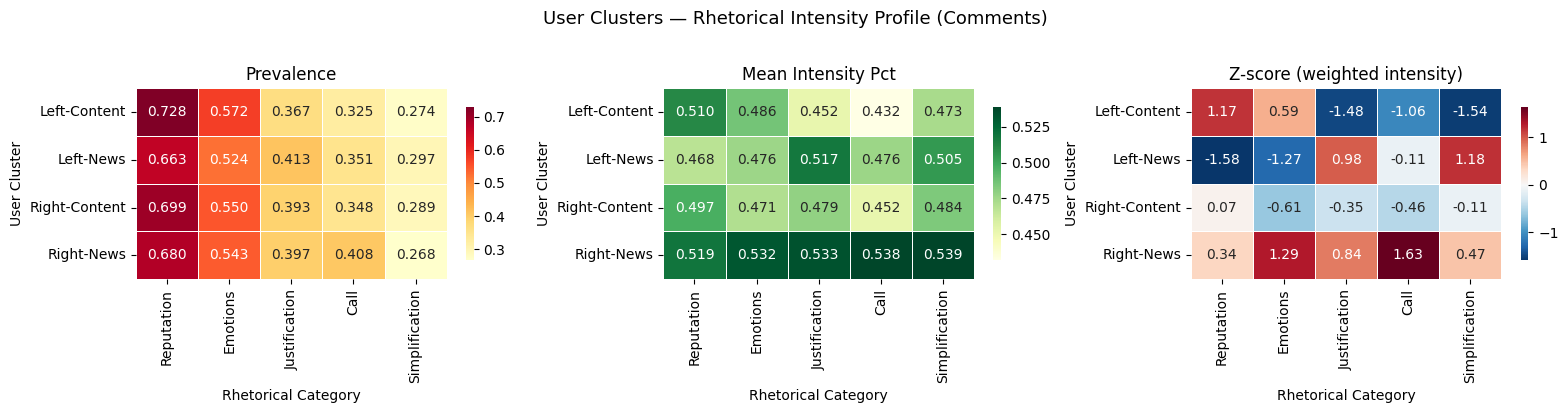


cluster_wi (raw weighted intensity):
category  Reputation  Emotions  Justification      Call  Simplification
cluster                                                                
0           0.311125  0.246909       0.214494  0.169412        0.147013
1           0.347654  0.257414       0.187268  0.158784        0.137523
2           0.353524  0.288082       0.211639  0.223081        0.141787
3           0.371875  0.276781       0.163996  0.140427        0.126942

cluster_zscore_users (z-scored — KEY OUTPUT):
category       Reputation  Emotions  Justification      Call  Simplification
cluster                                                                     
Left-Content     1.171345  0.589540      -1.482769 -1.056630       -1.541825
Left-News       -1.583531 -1.267252       0.984052 -0.114245        1.178942
Right-Content    0.072994 -0.614262      -0.345906 -0.459792       -0.107546
Right-News       0.339192  1.291974       0.844623  1.630667        0.470429


In [5]:
# ── PASS 2: re-read files for span data (clustered users only) ───────────────
# all_jsonl was built in Cell 3 and stays in scope.
# We stream through files again, process spans for valid users only,
# and collect only (user, category, coverage_share) rows — no text kept.
valid_users = set(analysis_users.index)
print(f"Processing spans for {len(valid_users):,} clustered users (pass 2)...")

comment_rows = []
n_files_done = 0

for file_idx, fp in enumerate(all_jsonl):
    if file_idx % 500 == 0:
        print(f"  [{file_idx:>5}/{len(all_jsonl)}] span rows so far: {len(comment_rows):,}", flush=True)
    with open(fp, encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            author = rec.get("AuthorName")
            if author not in valid_users:
                continue  # skip non-clustered users immediately

            ts = str(rec.get("Timestamp", ""))
            try:
                year = int(ts[:4])
            except ValueError:
                continue
            if not (START_YEAR <= year <= END_YEAR):
                continue

            if rec.get("predicted_stance") not in {0, 1, 2}:
                continue

            text     = rec.get("CommentText", "")
            text_len = len(text)
            if text_len == 0:
                continue

            # Group spans by category
            cat_spans = defaultdict(list)
            for pred in rec.get("span_predictions", []):
                tech = str(pred.get("technique", "")).lower()
                cat  = LABEL_MAPPING.get(tech)
                if cat is None:
                    continue
                for sp in pred.get("spans", []):
                    cat_spans[cat].append((sp.get("start"), sp.get("end")))

            for cat, spans in cat_spans.items():
                cov = merged_coverage(spans, text_len)
                if cov > 0:
                    comment_rows.append({
                        "user":           author,
                        "category":       cat,
                        "coverage_share": cov,
                    })

comment_df = pd.DataFrame(comment_rows)
print(f"\ncomment_df shape: {comment_df.shape}")
print(comment_df.head())


# ── STEP 2: Within-category percentile rank (full corpus) ────────────────────
comment_df["intensity_pct"] = comment_df.groupby("category")["coverage_share"].rank(
    method="average", pct=True
)


# ── STEP 3: User × category aggregation ──────────────────────────────────────
user_cat = (
    comment_df
    .groupby(["user", "category"])
    .agg(
        n_cat_comments    =("coverage_share", "size"),
        mean_intensity_pct=("intensity_pct",  "mean"),
    )
    .reset_index()
)

user_info = analysis_users[["n_comments", "cluster"]].reset_index()
user_cat = user_cat.merge(user_info, left_on="user", right_on="AuthorName", how="left")
user_cat["prevalence"]         = user_cat["n_cat_comments"] / user_cat["n_comments"]
user_cat["weighted_intensity"] = user_cat["prevalence"] * user_cat["mean_intensity_pct"]

print(f"\nuser_cat shape: {user_cat.shape}")
print(user_cat.head())


# ── STEP 4: Cluster × category aggregation ────────────────────────────────────
def pivot_cluster_cat(col):
    return (
        user_cat.groupby(["cluster", "category"])[col].mean()
        .unstack("category")
        .reindex(columns=CATEGORY_ORDER)
        .fillna(0)
    )

cluster_wi       = pivot_cluster_cat("weighted_intensity")
cluster_prev     = pivot_cluster_cat("prevalence")
cluster_mean_int = pivot_cluster_cat("mean_intensity_pct")


# ── STEP 5: Z-score column-wise (ddof=0) ─────────────────────────────────────
def zscore_cols(df):
    """Z-score each column independently (population std, ddof=0). Zero-std → 0."""
    return df.apply(
        lambda col: (col - col.mean()) / col.std(ddof=0)
        if col.std(ddof=0) > 0
        else pd.Series(0.0, index=col.index),
        axis=0,
    )

cluster_zscore_raw = zscore_cols(cluster_wi)
cluster_zscore_users = (
    cluster_zscore_raw
    .rename(index=CLUSTER_TO_GROUP)
    .reindex(GROUP_ORDER)
)


# ── PLOT: 3-panel heatmap ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
panels = [
    (cluster_prev.rename(index=CLUSTER_TO_GROUP).reindex(GROUP_ORDER),
     "Prevalence",                  "YlOrRd", ".3f", False),
    (cluster_mean_int.rename(index=CLUSTER_TO_GROUP).reindex(GROUP_ORDER),
     "Mean Intensity Pct",          "YlGn",   ".3f", False),
    (cluster_zscore_users,
     "Z-score (weighted intensity)", "RdBu_r", ".2f", True),
]
for ax, (data, title, cmap, fmt, centered) in zip(axes, panels):
    sns.heatmap(
        data, cmap=cmap, annot=True, fmt=fmt,
        linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
        center=0 if centered else None,
    )
    ax.set_title(title)
    ax.set_xlabel("Rhetorical Category")
    ax.set_ylabel("User Cluster")

plt.suptitle("User Clusters — Rhetorical Intensity Profile (Comments)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/user_cluster_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

print("\ncluster_wi (raw weighted intensity):")
print(cluster_wi.to_string())
print("\ncluster_zscore_users (z-scored — KEY OUTPUT):")
print(cluster_zscore_users.to_string())

Scanning transcript files...
  Found 6,008 JSONL files
  [    0/6008] videos kept: 0
  [  500/6008] videos kept: 420
  [ 1000/6008] videos kept: 851
  [ 1500/6008] videos kept: 1,317
  [ 2000/6008] videos kept: 1,785
  [ 2500/6008] videos kept: 2,254
  [ 3000/6008] videos kept: 2,742
  [ 3500/6008] videos kept: 3,224
  [ 4000/6008] videos kept: 3,713
  [ 4500/6008] videos kept: 4,200
  [ 5000/6008] videos kept: 4,615
  [ 5500/6008] videos kept: 5,097
  [ 6000/6008] videos kept: 5,587
  Kept 5,595 videos | Skipped 413 (< 350 words)
  Valid groups (>= 30 videos): {'Left-News': 2303, 'Right-Content': 402, 'Left-Content': 625, 'Right-News': 2265}

transcript_df shape: (19440, 5)
       videoId channelName channel_group       category  coverage_share
0  -09DzvdLaEw    ABC News     Left-News  Justification        0.014085
1  -09DzvdLaEw    ABC News     Left-News       Emotions        0.053304
2  -09DzvdLaEw    ABC News     Left-News     Reputation        0.008451
3  -3LDc4kkkyc    ABC News  

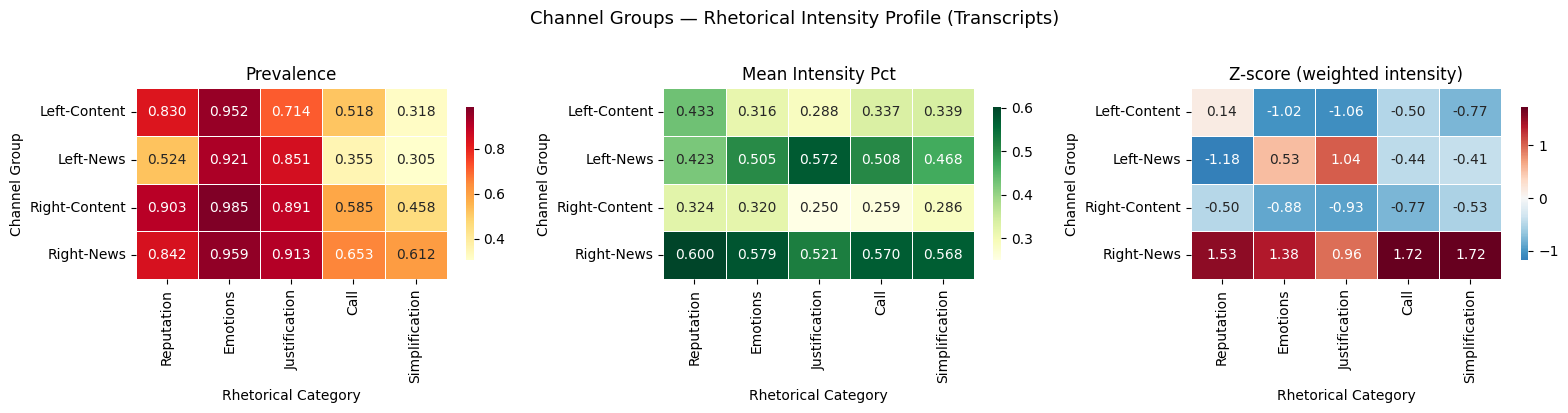


channel_group_wi (raw weighted intensity):
category       Reputation  Emotions  Justification      Call  Simplification
channel_group                                                               
Left-Content     0.359783  0.300913       0.205403  0.174798        0.108038
Left-News        0.221747  0.464927       0.486419  0.180282        0.142594
Right-Content    0.292976  0.315477       0.222580  0.151143        0.130764
Right-News       0.505375  0.555356       0.475684  0.372539        0.347910

channel_group_zscore (z-scored — KEY OUTPUT):
category       Reputation  Emotions  Justification      Call  Simplification
channel_group                                                               
Left-Content     0.141492 -1.020897      -1.062791 -0.504841       -0.770608
Left-News       -1.177073  0.525829       1.038705 -0.443167       -0.412149
Right-Content   -0.496671 -0.883555      -0.934338 -0.770861       -0.534863
Right-News       1.532252  1.378624       0.958425  1.718869  

In [6]:
# ── LOAD & FILTER TRANSCRIPTS ─────────────────────────────────────────────────
print("Scanning transcript files...")
trans_jsonl = sorted(glob.glob(os.path.join(TRANSCRIPTS_PATH, "**", "*.jsonl"), recursive=True))
print(f"  Found {len(trans_jsonl):,} JSONL files")

video_records = []   # one dict per qualifying video (text + spans kept only briefly)
n_skipped_words = 0

for file_idx, fp in enumerate(trans_jsonl):
    if file_idx % 500 == 0:
        print(f"  [{file_idx:>5}/{len(trans_jsonl)}] videos kept: {len(video_records):,}", flush=True)
    with open(fp, encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            text = rec.get("CommentText", "")
            if len(text.split()) < MIN_WORDS_TRANSCRIPT:
                n_skipped_words += 1
                continue

            leaning = str(rec.get("channel_leaning", "")).title()
            source  = str(rec.get("source", "")).title()
            if not leaning or not source or leaning == "None" or source == "None":
                continue

            video_records.append({
                "videoId":         rec.get("videoId", ""),
                "channelName":     rec.get("channelName", ""),
                "channel_group":   f"{leaning}-{source}",
                "CommentText":     text,
                "predicted_spans": rec.get("predicted_spans", {}),
            })

print(f"  Kept {len(video_records):,} videos | Skipped {n_skipped_words:,} (< {MIN_WORDS_TRANSCRIPT} words)")

# ── FILTER BY MIN_VIDEOS_CHANNEL ─────────────────────────────────────────────
group_counts_raw  = Counter(v["channel_group"] for v in video_records)
valid_groups      = {g for g, cnt in group_counts_raw.items() if cnt >= MIN_VIDEOS_CHANNEL}
video_records     = [v for v in video_records if v["channel_group"] in valid_groups]
video_group_counts = Counter(v["channel_group"] for v in video_records)
print(f"  Valid groups (>= {MIN_VIDEOS_CHANNEL} videos): {dict(video_group_counts)}")


# ── BUILD transcript_df (long form) ──────────────────────────────────────────
# predicted_spans is a dict: {technique_name: [{start, end}, ...]}
# One row per (video × category) with coverage_share > 0
transcript_rows = []
for v in video_records:
    text     = v["CommentText"]
    text_len = len(text)
    if text_len == 0:
        continue

    cat_spans = defaultdict(list)
    for tech, spans in v["predicted_spans"].items():
        cat = LABEL_MAPPING.get(tech.lower())
        if cat is None:
            continue
        for sp in spans:
            cat_spans[cat].append((sp.get("start"), sp.get("end")))

    for cat, spans in cat_spans.items():
        cov = merged_coverage(spans, text_len)
        if cov > 0:
            transcript_rows.append({
                "videoId":        v["videoId"],
                "channelName":    v["channelName"],
                "channel_group":  v["channel_group"],
                "category":       cat,
                "coverage_share": cov,
            })

# Free transcript text/spans from memory once rows are built
del video_records

transcript_df = pd.DataFrame(transcript_rows)
print(f"\ntranscript_df shape: {transcript_df.shape}")
print(transcript_df.head())


# ── STEP 3: Within-category percentile rank ───────────────────────────────────
transcript_df["intensity_pct"] = transcript_df.groupby("category")["coverage_share"].rank(
    method="average", pct=True
)


# ── STEP 4: channel_group × category aggregation ─────────────────────────────
channel_group_wi_rows = []
for grp in GROUP_ORDER:
    total = video_group_counts.get(grp, 0)
    if total == 0:
        continue
    for cat in CATEGORY_ORDER:
        mask = (transcript_df["channel_group"] == grp) & (transcript_df["category"] == cat)
        sub  = transcript_df[mask]
        n_with_cat = len(sub)
        prev     = n_with_cat / total
        mean_int = float(sub["intensity_pct"].mean()) if n_with_cat > 0 else 0.0
        channel_group_wi_rows.append({
            "channel_group":      grp,
            "category":           cat,
            "n_videos_with_cat":  n_with_cat,
            "prevalence":         prev,
            "mean_intensity_pct": mean_int,
            "weighted_intensity": prev * mean_int,
        })

channel_group_agg = pd.DataFrame(channel_group_wi_rows)

def pivot_grp_cat(col):
    return (
        channel_group_agg
        .pivot(index="channel_group", columns="category", values=col)
        .reindex(index=GROUP_ORDER, columns=CATEGORY_ORDER)
        .fillna(0)
    )

channel_group_wi       = pivot_grp_cat("weighted_intensity")
channel_group_prev     = pivot_grp_cat("prevalence")
channel_group_mean_int = pivot_grp_cat("mean_intensity_pct")
channel_group_zscore   = zscore_cols(channel_group_wi)


# ── PLOT: 3-panel heatmap ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
panels = [
    (channel_group_prev,     "Prevalence",                  "YlOrRd", ".3f", False),
    (channel_group_mean_int, "Mean Intensity Pct",          "YlGn",   ".3f", False),
    (channel_group_zscore,   "Z-score (weighted intensity)", "RdBu_r", ".2f", True),
]
for ax, (data, title, cmap, fmt, centered) in zip(axes, panels):
    sns.heatmap(
        data, cmap=cmap, annot=True, fmt=fmt,
        linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
        center=0 if centered else None,
    )
    ax.set_title(title)
    ax.set_xlabel("Rhetorical Category")
    ax.set_ylabel("Channel Group")

plt.suptitle("Channel Groups — Rhetorical Intensity Profile (Transcripts)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/channel_group_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nchannel_group_wi (raw weighted intensity):")
print(channel_group_wi.to_string())
print("\nchannel_group_zscore (z-scored — KEY OUTPUT):")
print(channel_group_zscore.to_string())

User cluster z-scores (rows = GROUP_ORDER):
category       Reputation  Emotions  Justification      Call  Simplification
cluster                                                                     
Left-Content     1.171345  0.589540      -1.482769 -1.056630       -1.541825
Left-News       -1.583531 -1.267252       0.984052 -0.114245        1.178942
Right-Content    0.072994 -0.614262      -0.345906 -0.459792       -0.107546
Right-News       0.339192  1.291974       0.844623  1.630667        0.470429

Channel group z-scores (rows = GROUP_ORDER):
category       Reputation  Emotions  Justification      Call  Simplification
channel_group                                                               
Left-Content     0.141492 -1.020897      -1.062791 -0.504841       -0.770608
Left-News       -1.177073  0.525829       1.038705 -0.443167       -0.412149
Right-Content   -0.496671 -0.883555      -0.934338 -0.770861       -0.534863
Right-News       1.532252  1.378624       0.958425  1.718869   

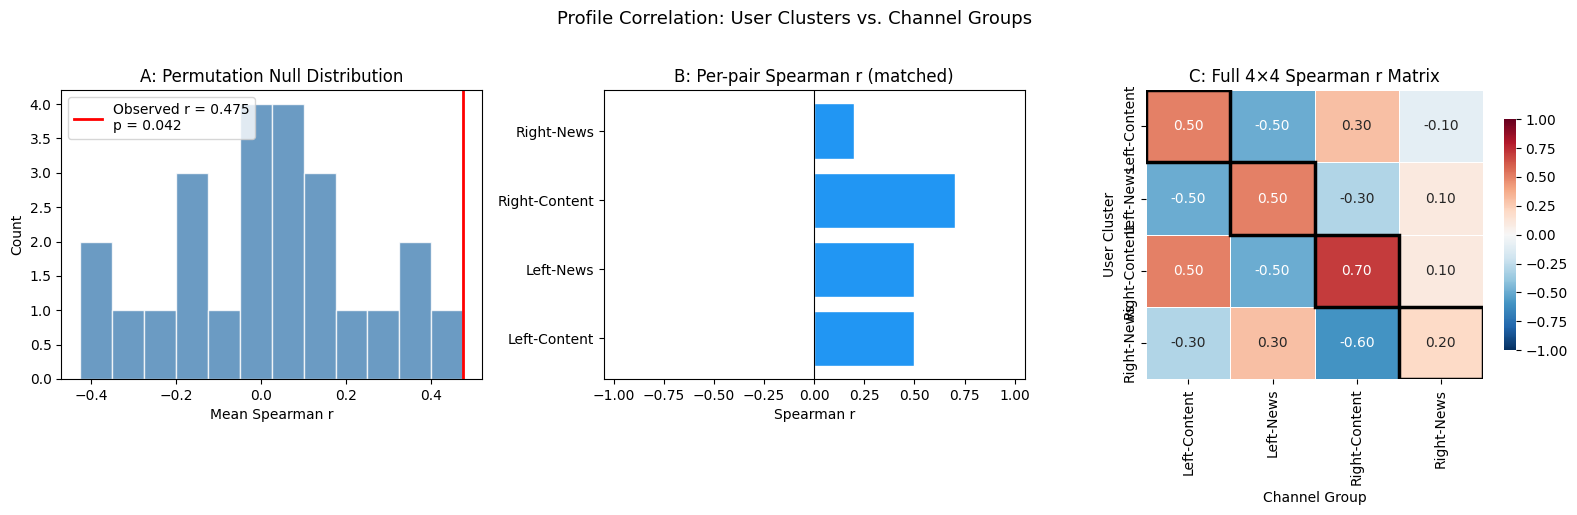

In [7]:
# ⚠️  If CLUSTER_TO_GROUP was adjusted in Cell 1, re-run Cells 4 and 5 first.

# ── STEP 1: Align both matrices to GROUP_ORDER ────────────────────────────────
user_z = cluster_zscore_users.reindex(GROUP_ORDER)
chan_z  = channel_group_zscore.reindex(GROUP_ORDER)

print("User cluster z-scores (rows = GROUP_ORDER):")
print(user_z.to_string())
print("\nChannel group z-scores (rows = GROUP_ORDER):")
print(chan_z.to_string())


# ── STEP 2: Per-pair Spearman + Pearson ───────────────────────────────────────
corr_rows = []
for grp in GROUP_ORDER:
    u_vec = user_z.loc[grp].values
    c_vec = chan_z.loc[grp].values
    rho, p_s = spearmanr(u_vec, c_vec)
    r,   p_p = pearsonr(u_vec, c_vec)
    corr_rows.append({
        "group":      grp,
        "spearman_r": rho,
        "p_spearman": p_s,
        "pearson_r":  r,
        "p_pearson":  p_p,
    })
corr_df = pd.DataFrame(corr_rows)


# ── STEP 3: Exhaustive permutation test (4! = 24) ────────────────────────────
n_groups = len(GROUP_ORDER)
identity = list(range(n_groups))

def mean_spearman_perm(perm):
    return float(np.mean([
        spearmanr(user_z.iloc[i].values, chan_z.iloc[perm[i]].values)[0]
        for i in range(n_groups)
    ]))

observed  = mean_spearman_perm(identity)
null_dist = np.array([mean_spearman_perm(list(p)) for p in permutations(identity)])
p_value   = float(np.mean(null_dist >= observed))


# ── STEP 4: Full 4×4 Spearman cross-matrix ────────────────────────────────────
cross_matrix = pd.DataFrame(index=GROUP_ORDER, columns=GROUP_ORDER, dtype=float)
for u_grp in GROUP_ORDER:
    for c_grp in GROUP_ORDER:
        rho, _ = spearmanr(user_z.loc[u_grp].values, chan_z.loc[c_grp].values)
        cross_matrix.loc[u_grp, c_grp] = float(rho)


# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
print("\nPer-pair correlations:")
print(corr_df.to_string(index=False))
print(f"\nMean Spearman r (matched pairs):  {observed:.4f}")
print(f"Permutation p-value ({len(null_dist)} perms): {p_value:.4f}")
print(f"Null distribution:  mean = {null_dist.mean():.4f}  std = {null_dist.std():.4f}")
print("\nFull 4×4 cross-matrix (Spearman r):")
print(cross_matrix.to_string())


# ── PLOT: 3-panel figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(null_dist, bins=12, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(
    observed, color="red", lw=2,
    label=f"Observed r = {observed:.3f}\np = {p_value:.3f}",
)
axes[0].set_xlabel("Mean Spearman r")
axes[0].set_ylabel("Count")
axes[0].set_title("A: Permutation Null Distribution")
axes[0].legend()

colors = ["#2196F3" if r >= 0 else "#F44336" for r in corr_df["spearman_r"]]
axes[1].barh(corr_df["group"], corr_df["spearman_r"], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("Spearman r")
axes[1].set_title("B: Per-pair Spearman r (matched)")
axes[1].set_xlim(-1.05, 1.05)

ax = axes[2]
sns.heatmap(
    cross_matrix.astype(float), annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
    xticklabels=GROUP_ORDER, yticklabels=GROUP_ORDER,
)
for i in range(n_groups):
    ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False, edgecolor="black", lw=2.5))
ax.set_title("C: Full 4×4 Spearman r Matrix")
ax.set_xlabel("Channel Group")
ax.set_ylabel("User Cluster")

plt.suptitle("Profile Correlation: User Clusters vs. Channel Groups", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
cluster_zscore_users.to_csv(f"{OUTPUT_DIR}/user_cluster_zscore.csv")
channel_group_zscore.to_csv(f"{OUTPUT_DIR}/channel_group_zscore.csv")
corr_df.to_csv(f"{OUTPUT_DIR}/profile_correlations.csv", index=False)
cross_matrix.to_csv(f"{OUTPUT_DIR}/cross_correlation_matrix.csv")

artifacts = [
    "user_cluster_zscore.csv",
    "channel_group_zscore.csv",
    "profile_correlations.csv",
    "cross_correlation_matrix.csv",
    "cluster_channel_heatmap.png",
    "user_cluster_intensity.png",
    "channel_group_intensity.png",
    "correlation_analysis.png",
]
print(f"Saved to {OUTPUT_DIR}/:")
for fn in artifacts:
    path = os.path.join(OUTPUT_DIR, fn)
    status = "ok" if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {fn}")

Saved to output/:
  [ok] user_cluster_zscore.csv
  [ok] channel_group_zscore.csv
  [ok] profile_correlations.csv
  [ok] cross_correlation_matrix.csv
  [ok] cluster_channel_heatmap.png
  [ok] user_cluster_intensity.png
  [ok] channel_group_intensity.png
  [ok] correlation_analysis.png
